In [40]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import plotly.graph_objects as go
from plotly.subplots import make_subplots

%matplotlib inline

RESULTS_DIR = Path("evals/experiments")
PLOTS_DIR   = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
PLOTS_NO_ANSWARE_DIR   = Path("plots/no_answare")
PLOTS_NO_ANSWARE_DIR.mkdir(exist_ok=True)

K_VALUES = [3, 4, 5, 6]
ALL_METRICS = [
    "answer_correctness",
    "faithfulness",
    "response_relevancy",
    "context_precision",
    "context_recall",
]
NO_ANSWARE_METRICS = ["faithfulness", "context_precision"]

INDEX_LABELS = {
    "sentence":              "Sliding-window",
    "markdown":              "Structured (no chunk size param)",
    "markdown_and_sentence": "Hybrid",
}
INDEX_COLORS = {
    "sentence":              "#648FFF",
    "markdown":              "#FE6100",
    "markdown_and_sentence": "#785EF0",
}
INDEX_TYPES = list(INDEX_COLORS.keys())


def build_filename(index_type: str, k: int, chunk_size: int, no_answare: bool = False) -> Path:
    na   = "_no_answare" if no_answare else ""
    base = RESULTS_DIR / ("no_answare" if no_answare else "")
    if index_type == "sentence":
        name = f"from_index_sentence{na}_{chunk_size}_k_{k}_results.csv"
    elif index_type == "markdown":
        name = f"from_index_markdown{na}_k_{k}_results.csv"
    else:
        name = f"from_index_markdown_and_sentence{na}_{chunk_size}_k_{k}_results.csv"
    return base / name


def load_all_results(chunk_size: int, no_answare: bool = False) -> pd.DataFrame:
    frames = []
    for index_type in INDEX_TYPES:
        for k in K_VALUES:
            path = build_filename(index_type, k, chunk_size, no_answare)
            if not path.exists():
                print(f"[WARNING] File not found, skipping: {path}")
                continue
            df = pd.read_csv(path).dropna(subset=["question"])
            df["index_type"] = index_type
            df["k"]          = k
            frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No CSVs found.")
    return pd.concat(frames, ignore_index=True)


def pass_stats(df: pd.DataFrame) -> pd.DataFrame:
    grp   = df.groupby(["index_type", "k"])
    stats = grp["judge_result"].apply(
        lambda s: (s.str.lower() == "pass").sum()
    ).rename("pass_count").reset_index()
    stats["total"]     = grp["judge_result"].count().values
    stats["pass_rate"] = stats["pass_count"] / stats["total"] * 100
    return stats


def metric_means(df: pd.DataFrame, metrics: list[str], filter_absent: bool = False) -> pd.DataFrame:
    available = [m for m in metrics if m in df.columns]
    if filter_absent:
        df = df[df["answer_source"] != "absent for choice"]
    return df.groupby(["index_type", "k"])[available].mean().reset_index()


def plot_pass_rate(stats: pd.DataFrame, save_path: Path, title: str, index_labels: dict) -> None:
    fig = go.Figure()

    for idx_type in INDEX_TYPES:
        subset = stats[stats["index_type"] == idx_type].sort_values("k")
        values = subset["pass_rate"].values
        x_labels = [f"k={k}" for k in subset["k"].values]

        fig.add_trace(
            go.Bar(
                x=x_labels,
                y=values,
                name=index_labels[idx_type],
                marker_color=INDEX_COLORS[idx_type],
                text=[f"{v:.0f}%" for v in values],
                textposition="outside",
                textfont=dict(size=10),
            )
        )

    fig.add_annotation(
        text="<b>Pass rate (%)</b>",
        xref="paper", yref="paper",
        x=0.04, y=1.0,
        showarrow=False,
        font=dict(size=11, color="#444"),
        xanchor="right",
        yanchor="bottom",
    )

    fig.update_layout(
        title=dict(
            text=title,
            font=dict(size=14, weight="bold"),
            x=0.5,
            xanchor="center",
        ),
        barmode="group",
        xaxis=dict(
            title=dict(text="<b>Top k chunks retrieved</b>", font=dict(size=12)),
            tickangle=0,
            tickfont=dict(size=12),
            showline=False,
            linecolor="rgba(0,0,0,0.5)",
            linewidth=1,
        ),
        yaxis=dict(
            # title=dict(text="<b>Pass rate (%)</b>", font=dict(size=12)),
            range=[0, 115],          # extra space for the text labels above bars
            tickvals=list(range(0, 101, 20)),
            tickfont=dict(size=10),
            gridcolor="rgba(0,0,0,0.08)",
            gridwidth=1,
            showgrid=True,
            showline=False,
            linecolor="rgba(0,0,0,0.5)",
            linewidth=1,
            ticklabelstandoff=6,
        ),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1,
            font=dict(size=11),
        ),
        height=450,
        width=750,
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(t=100, b=60, l=80, r=40),
    )

    fig.write_image(str(save_path), scale=2)
    fig.show()
    print(f"Saved: {save_path}")

def plot_metrics_lines(means: pd.DataFrame, save_path: Path, metrics: list[str], index_labels: dict) -> None:
    available = [m for m in metrics if m in means.columns]
    ncols = 3
    nrows = (len(available) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows), squeeze=False)
    fig.suptitle("RAGAS Metrics by Index Type and k", fontsize=14, fontweight="bold")
    for ax_idx, metric in enumerate(available):
        ax = axes[ax_idx // ncols][ax_idx % ncols]
        for idx_type in INDEX_TYPES:
            subset = means[means["index_type"] == idx_type].sort_values("k")
            ax.plot(
                subset["k"], subset[metric],
                marker="o", label=index_labels[idx_type],
                color=INDEX_COLORS[idx_type], linewidth=2, markersize=6,
            )
        ax.set_title(metric.replace("_", " ").title(), fontsize=11)
        ax.set_xlabel("k")
        ax.set_ylabel("Score")
        ax.set_xticks(K_VALUES)
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=7.5, loc="lower right")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(linestyle="--", alpha=0.4)
    for ax_idx in range(len(available), nrows * ncols):
        axes[ax_idx // ncols][ax_idx % ncols].set_visible(False)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


def plot_single_metric_boxplot(
    df: pd.DataFrame,
    save_path: Path,
    metric: str,
    index_labels: dict,
    suptitle: str,
) -> None:
    if metric not in df.columns:
        print(f"[WARNING] Metric '{metric}' not found, skipping.")
        return

    fig = go.Figure()
    rng = np.random.default_rng(42)

    for index_type in INDEX_TYPES:
        label = index_labels[index_type]
        color = INDEX_COLORS[index_type]

        x_all, y_all = [], []
        for k in K_VALUES:
            vals = df[
                (df["index_type"] == index_type) & (df["k"] == k)
            ][metric].dropna().values
            x_all.extend([f"k={k}"] * len(vals))
            y_all.extend(vals.tolist())

        fig.add_trace(
            go.Box(
                x=x_all,
                y=y_all,
                name=label,
                marker_color=color,
                fillcolor=color,
                opacity=0.7,
                boxmean=False,
                showlegend=True,
                legendgroup=label,
                boxpoints="all",
                jitter=0.4,
                pointpos=0,
                marker=dict(color=color, size=4, opacity=0.25, line=dict(width=0)),
                line=dict(color=color, width=1.5),
            )
        )

    fig.add_annotation(
        text="<b>Score</b>",
        xref="paper", yref="paper",
        x=-0.02, y=1.0,
        showarrow=False,
        font=dict(size=11, color="#444"),
        xanchor="right",
        yanchor="bottom",
    )

    fig.update_layout(
        title=dict(
            text=suptitle,
            font=dict(size=14, weight="bold"),
            x=0.5,
            xanchor="center",
        ),
        xaxis=dict(
            tickangle=0,
            tickfont=dict(size=12),
            title=dict(text="<b>Top k chunks retrieved</b>", font=dict(size=12)),
            categoryorder="array",
            categoryarray=[f"k={k}" for k in K_VALUES],
            showline=False,
            linecolor="rgba(0,0,0,0.5)",
            linewidth=1,
        ),
        yaxis=dict(
            range=[0.0, 1.1],
            tickvals=[0, 0.25, 0.5, 0.75, 1.0],
            tickfont=dict(size=10),
            gridcolor="rgba(0,0,0,0.08)",
            gridwidth=1,
            showgrid=True,
            showline=False,
            linecolor="rgba(0,0,0,0.5)",
            linewidth=1,
            ticklabelstandoff=6,
            title="",
        ),
        boxmode="group",
        boxgap=0.2,
        boxgroupgap=0.1,
        height=450,
        width=900,
        paper_bgcolor="white",
        plot_bgcolor="white",
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1,
            font=dict(size=11),
        ),
        margin=dict(t=100, b=60, l=80, r=40),
    )

    fig.write_image(str(save_path), scale=2)
    fig.show()
    print(f"Saved: {save_path}")


# INDEX WITH CHNK SIZE 512

Saved: plots/512_pass_rate.png


Saved: plots/boxplot_512_answer_correctness.png


Saved: plots/boxplot_512_faithfulness.png


Saved: plots/boxplot_512_response_relevancy.png


Saved: plots/boxplot_512_context_precision.png


Saved: plots/boxplot_512_context_recall.png


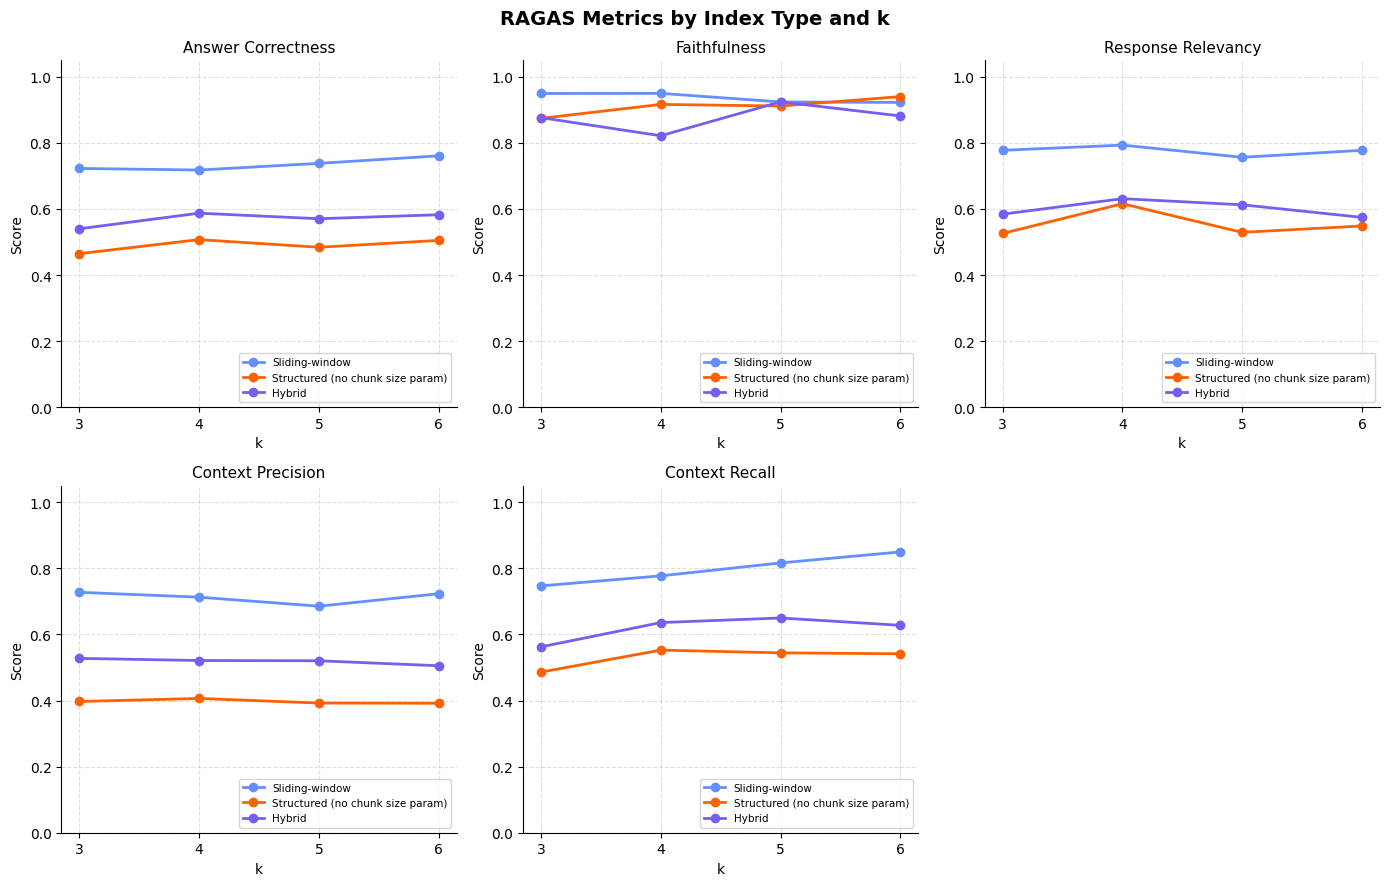

Saved: plots/2_metrics_lines.png


In [41]:
CHUNK_SIZE = 512
OVERLAP_SIZE = 50
df    = load_all_results(chunk_size=CHUNK_SIZE)
stats = pass_stats(df)
means = metric_means(df, ALL_METRICS, filter_absent=True)

plot_pass_rate(stats, PLOTS_DIR / "512_pass_rate.png",
               f"Judge Pass Results by Index Type and k (chunk size {CHUNK_SIZE} and overlap {OVERLAP_SIZE})", INDEX_LABELS)

for metric in ALL_METRICS:
    plot_single_metric_boxplot(
        df,
        PLOTS_DIR / f"boxplot_{CHUNK_SIZE}_{metric}.png",
        metric,
        INDEX_LABELS,
        f"{metric.replace('_', ' ').title()} — chunk size {CHUNK_SIZE} and overlap {OVERLAP_SIZE}",
    )

plot_metrics_lines(means, PLOTS_DIR / "2_metrics_lines.png", ALL_METRICS, INDEX_LABELS)

# INDEX WITH CHUNK SIZE 1024

Saved: plots/1024_pass_rate.png


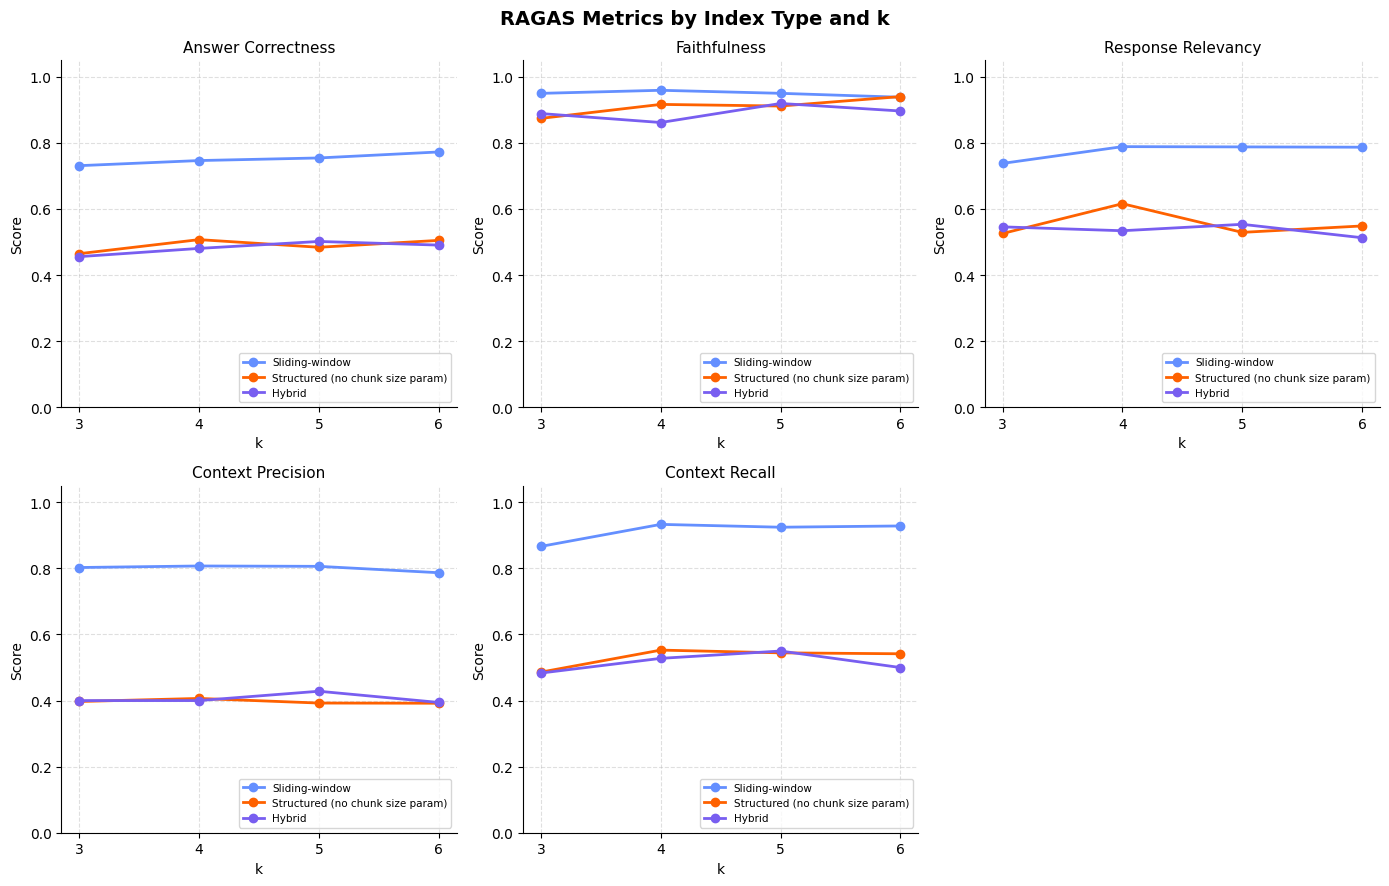

Saved: plots/2_metrics_lines.png


Saved: plots/boxplot_1024_answer_correctness.png


Saved: plots/boxplot_1024_faithfulness.png


Saved: plots/boxplot_1024_response_relevancy.png


Saved: plots/boxplot_1024_context_precision.png


Saved: plots/boxplot_1024_context_recall.png


In [42]:
CHUNK_SIZE = 1024
CHUNK_OVERLAP_SIZE = 100
df    = load_all_results(chunk_size=CHUNK_SIZE)
stats = pass_stats(df)
means = metric_means(df, ALL_METRICS, filter_absent=True)

plot_pass_rate(stats, PLOTS_DIR / "1024_pass_rate.png",
               f"Judge Pass Results by Index Type and k (chunk size {CHUNK_SIZE} and overlap {CHUNK_OVERLAP_SIZE})", INDEX_LABELS)

plot_metrics_lines(means, PLOTS_DIR / "2_metrics_lines.png", ALL_METRICS, INDEX_LABELS)

for metric in ALL_METRICS:
    plot_single_metric_boxplot(
        df,
        PLOTS_DIR / f"boxplot_{CHUNK_SIZE}_{metric}.png",
        metric,
        INDEX_LABELS,
        f"{metric.replace('_', ' ').title()} — chunk size {CHUNK_SIZE} and overlap {CHUNK_OVERLAP_SIZE}",


    )

# NO ANSWARE: 512

Saved: plots/no_answare/512_no_answare_pass_rate.png


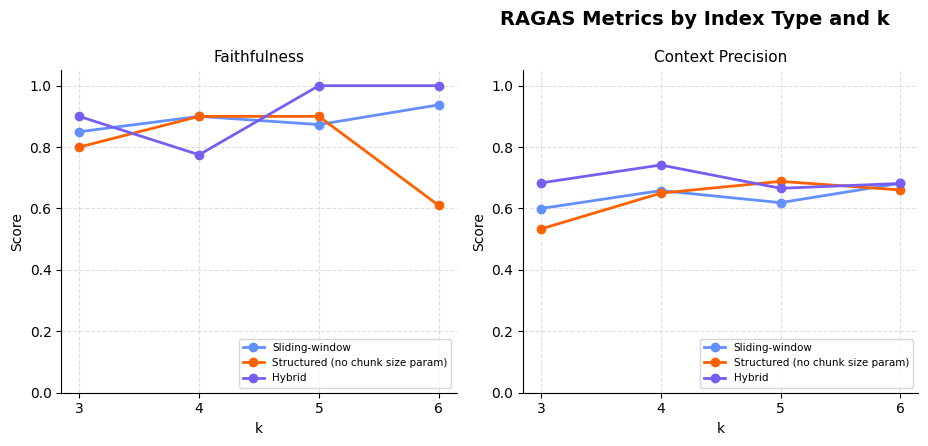

Saved: plots/no_answare/512_no_answare_metrics_lines.png


Saved: plots/no_answare/boxplot_no_answare_512_faithfulness.png


Saved: plots/no_answare/boxplot_no_answare_512_context_precision.png


In [43]:
CHUNK_SIZE = 512
OVERLAP_SIZE = 50
df    = load_all_results(chunk_size=CHUNK_SIZE, no_answare=True)
stats = pass_stats(df)
means = metric_means(df, NO_ANSWARE_METRICS)

plot_pass_rate(stats, PLOTS_NO_ANSWARE_DIR / "512_no_answare_pass_rate.png",
               f"Judge Pass Results by Index Type and k (chunk size {CHUNK_SIZE} and overlap {OVERLAP_SIZE})", INDEX_LABELS)
plot_metrics_lines(means, PLOTS_NO_ANSWARE_DIR / "512_no_answare_metrics_lines.png", NO_ANSWARE_METRICS, INDEX_LABELS)

# plot_metrics_boxplots(df, PLOTS_NO_ANSWARE_DIR / "3_metrics_boxplots.png", NO_ANSWARE_METRICS, INDEX_LABELS,
#                       f"RAGAS Metrics Distribution by Index Type — chunk size {CHUNK_SIZE} (all k pooled)")



for metric in NO_ANSWARE_METRICS:
    plot_single_metric_boxplot(
        df,
        PLOTS_NO_ANSWARE_DIR / f"boxplot_no_answare_{CHUNK_SIZE}_{metric}.png",
        metric,
        INDEX_LABELS,
        f"{metric.replace('_', ' ').title()} — chunk size {CHUNK_SIZE} and overlap {OVERLAP_SIZE}",
    )

# NO ANSWARE: 1024

Saved: plots/no_answare/1_pass_rate.png


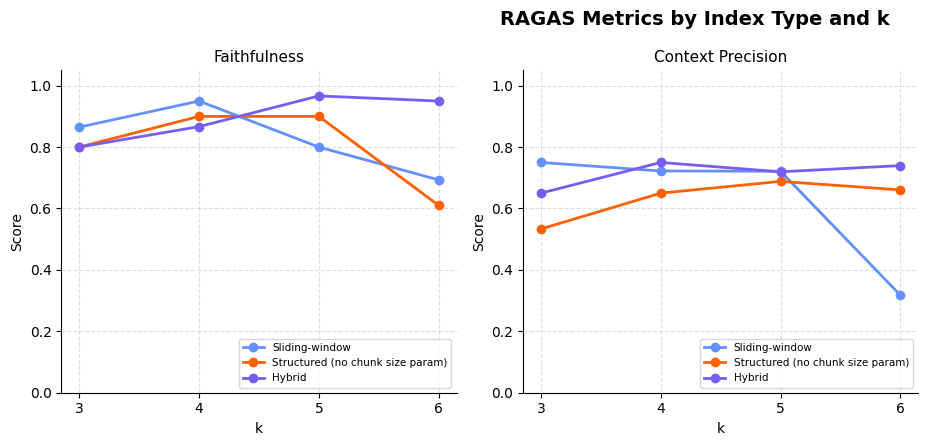

Saved: plots/no_answare/2_metrics_lines.png


Saved: plots/no_answare/boxplot_no_answare_1024_faithfulness.png


Saved: plots/no_answare/boxplot_no_answare_1024_context_precision.png


In [44]:
CHUNK_SIZE = 1024
OVERLAP_SIZE = 100
df    = load_all_results(chunk_size=CHUNK_SIZE, no_answare=True)
stats = pass_stats(df)
means = metric_means(df, NO_ANSWARE_METRICS)

plot_pass_rate(stats, PLOTS_NO_ANSWARE_DIR / "1_pass_rate.png",
               f"Judge Pass Results by Index Type and k (chunk size {CHUNK_SIZE} and overlap {OVERLAP_SIZE})", INDEX_LABELS)
plot_metrics_lines(means, PLOTS_NO_ANSWARE_DIR / "2_metrics_lines.png", NO_ANSWARE_METRICS, INDEX_LABELS)


for metric in NO_ANSWARE_METRICS:
    plot_single_metric_boxplot(
        df,
        PLOTS_NO_ANSWARE_DIR / f"boxplot_no_answare_{CHUNK_SIZE}_{metric}.png",
        metric,
        INDEX_LABELS,
        f"{metric.replace('_', ' ').title()} — chunk size {CHUNK_SIZE} and overlap {OVERLAP_SIZE}",
    )

# My chatbot vs PERPLEXITY

In [46]:
BAR_PASS_COLOR = "#2ecc71"
BAR_FAIL_COLOR = "#e74c3c"


def _pass_counts(path: Path) -> tuple[int, int]:
    df_tmp = pd.read_csv(path).dropna(subset=["question"])
    passes = int((df_tmp["judge_result"].str.lower() == "pass").sum())
    return passes, len(df_tmp) - passes


def plot_bar_comparison(save_path: Path) -> None:
    path_rag = Path("evals/experiments/from_index_sentence_1024_k_6_results.csv")
    path_prx = Path("evals/experiments/perplexity_results.csv")

    rag_pass, rag_fail = _pass_counts(path_rag)
    prx_pass, prx_fail = _pass_counts(path_prx)

    rag_total = rag_pass + rag_fail
    prx_total = prx_pass + prx_fail

    systems     = ["My RAG", "Perplexity AI"]
    pass_rates  = [rag_pass / rag_total, prx_pass / prx_total]

    fig = go.Figure()

    fig.add_trace(
        go.Bar(
            x=systems,
            y=pass_rates,
            marker_color=BAR_PASS_COLOR,
            showlegend=False,
            width=0.35,             # narrower bars
        )
    )

    fig.add_annotation(
        text="<b>Pass rate</b>",
        xref="paper", yref="paper",
        x=-0.02, y=1.0,
        showarrow=False,
        font=dict(size=11, color="#444"),
        xanchor="right",
        yanchor="bottom",
    )

    fig.update_layout(
        title=dict(
            text="<b>Correct answers: My RAG vs Perplexity</b>",
            font=dict(size=14),
            x=0.5,
            xanchor="center",
        ),
        xaxis=dict(
            tickangle=0,
            tickfont=dict(size=12),
            showline=True,
            linecolor="rgba(0,0,0,0.5)",
            linewidth=1,
        ),
        yaxis=dict(
            range=[0, 1.1],
            tickvals=[0, 0.25, 0.5, 0.75, 1.0],
            tickformat=".0%",       # formats 0.75 → "75%"
            tickfont=dict(size=10),
            gridcolor="rgba(0,0,0,0.08)",
            gridwidth=1,
            showgrid=True,
            showline=True,
            linecolor="rgba(0,0,0,0.5)",
            linewidth=1,
            ticklabelstandoff=6,
            title="",
        ),
        height=450,
        width=450,
        paper_bgcolor="white",
        plot_bgcolor="white",
        margin=dict(t=100, b=60, l=100, r=40),
    )

    fig.write_image(str(save_path), scale=2)
    fig.show()
    print(f"Saved: {save_path}")


plot_bar_comparison(PLOTS_DIR / "rag_vs_perplexity.png")

Saved: plots/rag_vs_perplexity.png
